just chilling before going to sleep...

In [1]:
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision.transforms import Compose, Normalize, ToTensor
from tqdm import tqdm

In [3]:
DATA_DIR = Path("./data")

DATA_DIR

PosixPath('data')

In [4]:
transforms = Compose([ToTensor(), Normalize((.5,), (.5,))])
ds_train = MNIST(root=DATA_DIR, train=True, transform=transforms)
ds_validate = MNIST(root=DATA_DIR, train=False, transform=transforms)

In [5]:
ds_train[0][0].shape

torch.Size([1, 28, 28])

In [6]:
ds_train_img = torch.stack([ds_train[i][0] for i in range(len(ds_train))])  
ds_validate_img = torch.stack([ds_validate[i][0] for i in range(len(ds_validate))])  

In [7]:
ds_train_img[0][0].shape,ds_train_img[0].shape

(torch.Size([28, 28]), torch.Size([1, 28, 28]))

In [8]:
ds_train_img = ds_train_img.float().squeeze(1)
ds_validate_img = ds_validate_img.float().squeeze(1)

In [9]:
ds_train_img.shape

torch.Size([60000, 28, 28])

In [10]:
ds_train_label = torch.stack([torch.Tensor([ds_train[i][1]]) for i in range(len(ds_train))])  
ds_validate_label = torch.stack([torch.Tensor([ds_validate[i][1]]) for i in range(len(ds_validate))])

In [11]:
ds_train_label.shape

torch.Size([60000, 1])

In [12]:
ds_train_label.squeeze(1).shape

torch.Size([60000])

In [13]:
train_ds = list(zip(ds_train_img.view(-1, 28*28), ds_train_label))
validate_ds = list(zip(ds_validate_img.view(-1, 28*28), ds_validate_label))

In [14]:
train_ds[0][0].shape, train_ds[0][1].shape

(torch.Size([784]), torch.Size([1]))

In [15]:
train_dl = DataLoader(train_ds, batch_size=256, shuffle=True)
valid_dl = DataLoader(validate_ds, batch_size=256)

In [16]:
xb, yb = next(iter(train_dl))

xb.shape, yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

In [17]:
xb.shape[1], yb.dtype

(784, torch.float32)

In [18]:
IN_PARMS = xb.shape[1]
OUT_PARMS = 10

model = nn.Sequential(
    nn.Linear(IN_PARMS, 64),
    nn.LeakyReLU(),
    nn.Linear(64, OUT_PARMS)
)

In [19]:
optimizer = Adam(params=model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [26]:
@torch.no_grad
def validate(model, dl):
    total_loss = 0
    correct = 0
    total = 0
    for xb, yb in dl:
        yb = yb.squeeze(1).long()
        preds = model(xb)
        loss = criterion(preds, yb)
        total_loss += loss.item()

        pred_classes = preds.argmax(dim=1)
        correct += (pred_classes == yb).sum().item()
        total += yb.size(0)
    accuracy = correct / total
    return total_loss, accuracy

In [21]:
EPOCH = 100

losses = []
for i in tqdm(range(EPOCH)):
    total_loss = 0
    for xb, yb in train_dl:
        preds = model(xb)
        loss = criterion(preds, yb.squeeze(1).long())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    losses.append(total_loss)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:27<00:00,  3.58it/s]


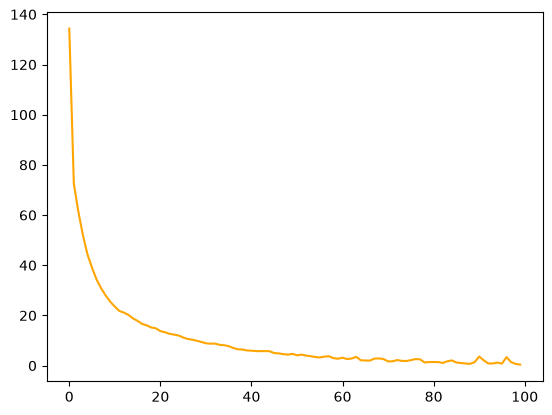

In [22]:
plt.plot(losses, label="train", color="orange")
plt.show()

In [27]:
model.eval()

validate(model, valid_dl)


(5.639780478298007, 0.973)

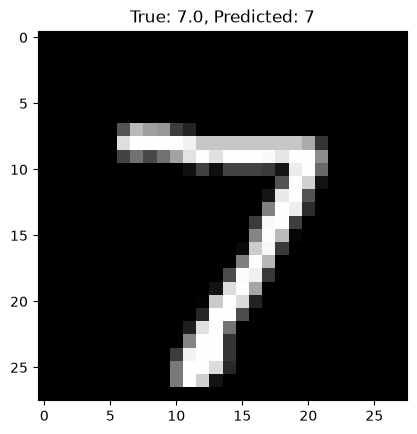

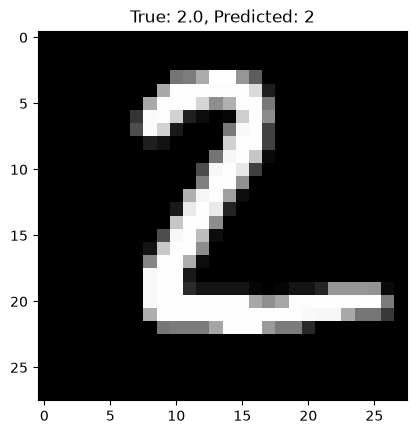

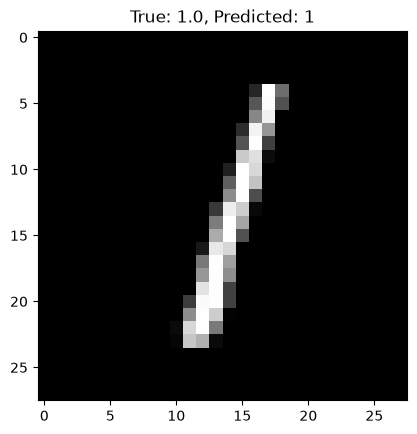

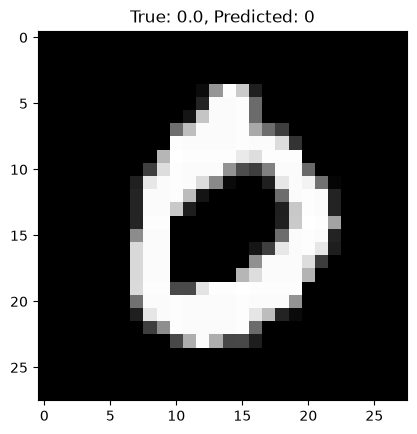

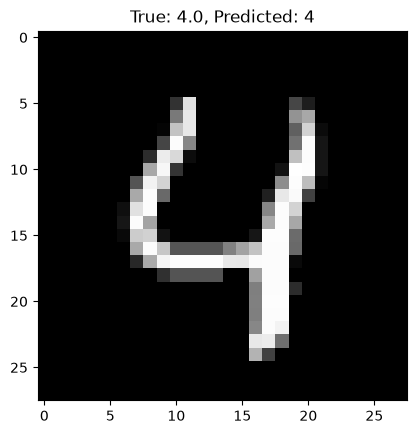

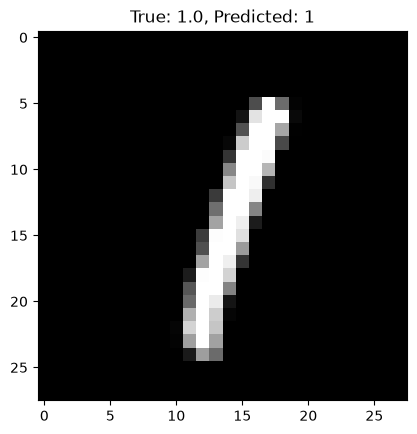

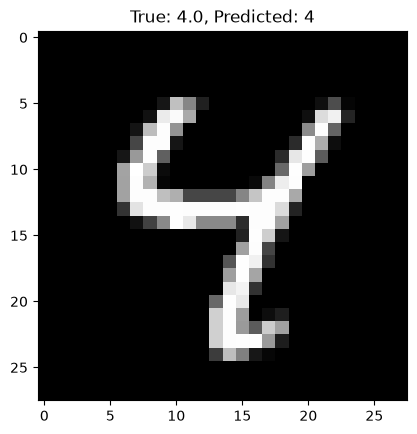

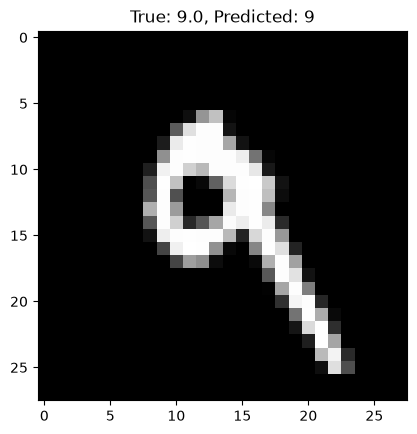

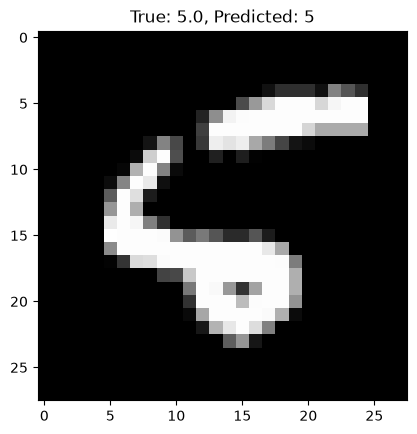

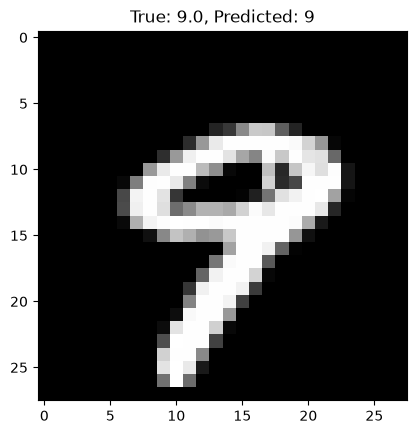

In [ ]:
xb, yb = next(iter(valid_dl))
preds = model(xb).argmax(dim=1)

for i in range(10):
    img = xb[i]
    true_label = yb[i].item()
    pred_label = preds[i].item()

    plt.imshow(img.view(28, 28), cmap='gray')
    plt.title(f"True: {true_label}, Predicted: {pred_label}")
    plt.show()

In [45]:
class MNISTInference(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        x = (x - 0.5) / 0.5 
        x = x.view(x.size(0), -1)
        logits = self.model(x)
        return logits

In [46]:
wrapper = MNISTInference(model)
wrapper.eval()

dummy_input = torch.randint(1, (1, 1, 28, 28), dtype=torch.float32)

In [48]:
%%capture
torch.onnx.export(
    wrapper,
    dummy_input,
    DATA_DIR / "mnist.onnx",
    input_names=["image"],
    output_names=["predicted_class"],
    dynamic_axes={"image": {0: "batch_size"}, "predicted_class": {0: "batch_size"}},
    external_data=False,
)